<h1>CHARGEMENT & EXPLORATION DES DONNÉES</h1>

In [ ]:
import pandas as pd
import numpy as np
import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


<h3>Charger les fichiers JSON</h3>

In [2]:
# Chemins
attack_path = "../data/attack/*.json"
benign_path = "../data/benign/*.json"

attack_files = glob.glob(attack_path)
benign_files = glob.glob(benign_path)

len(attack_files), len(benign_files)


(233, 1)

<h3>Fonction de chargement JSON</h3>

In [5]:
def load_json_files(file_list, label):
    data = []
    for file in file_list:
        with open(file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        record = json.loads(line)
                        record["label"] = label
                        data.append(record)
                    except json.JSONDecodeError:
                        continue
    return pd.DataFrame(data)


<h3>Créer les DataFrames</h3>

In [6]:
df_attack = load_json_files(attack_files, 1)
df_benign = load_json_files(benign_files, 0)

df = pd.concat([df_attack, df_benign], ignore_index=True)


<h3>Première inspection</h3>

In [10]:
df.shape


(1165012, 4)

In [11]:
df["label"].value_counts()


label
0    874923
1    290089
Name: count, dtype: int64

In [12]:
df.head()


,general,@timestamp,mqtt,label
0,"{'device_name': 'ard-w-01', 'application': 'We...",2025-01-16T14:20:11.418Z,"{'retained': False, 'qos': 0, 'message_value':...",1
1,"{'device_name': 'ard-w-01', 'application': 'We...",2025-01-16T14:20:11.419Z,"{'retained': False, 'qos': 0, 'message_value':...",1
2,"{'device_name': 'ard-w-01', 'application': 'We...",2025-01-16T14:20:11.419Z,"{'retained': False, 'qos': 0, 'message_value':...",1
3,"{'device_name': 'ard-w-15', 'application': 'Li...",2025-01-16T14:20:11.557Z,"{'retained': False, 'qos': 0, 'message_value':...",1
4,"{'device_name': 'ard-w-07', 'application': 'Ga...",2025-01-16T14:20:11.607Z,"{'retained': False, 'qos': 0, 'message_value':...",1


In [13]:
df.columns


Index(['general', '@timestamp', 'mqtt', 'label'], dtype='object')

<h3>Mini analyse visuelle</h3>

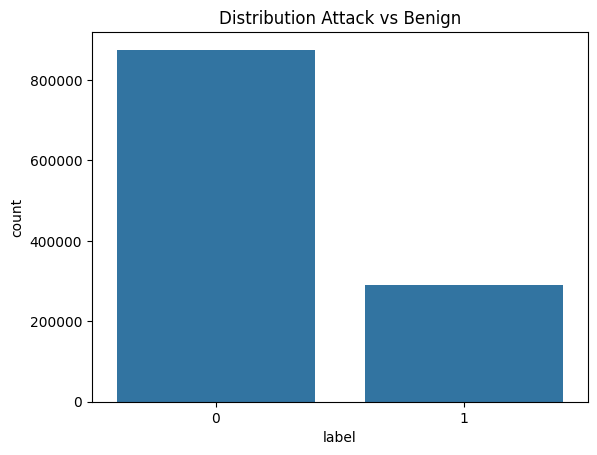

In [14]:
sns.countplot(x="label", data=df)
plt.title("Distribution Attack vs Benign")
plt.show()


<h1>NETTOYAGE & STRUCTURATION (CRUCIALE)</h1>

<h5>Problème actuel</h5>

Tes colonnes principales sont imbriquées (dict) :

general → infos device / application

mqtt → contenu & comportement réseau

@timestamp → temps (clé pour Reconnaissance)

👉 Les modèles ML ne savent pas travailler avec des dictionnaires.

➡️ On doit aplatir (flatten) ces champs.

<h3>Conversion du timestamp</h3>

In [15]:
df["@timestamp"] = pd.to_datetime(df["@timestamp"])
df = df.sort_values("@timestamp")

In [16]:
df["@timestamp"].min(), df["@timestamp"].max()


(Timestamp('2025-01-15 13:04:56.048000+0000', tz='UTC'),
 Timestamp('2025-09-10 02:09:39.932000+0000', tz='UTC'))

<h3>Aplatir general</h3>

In [17]:
general_df = pd.json_normalize(df["general"])
general_df.columns = [f"general_{c}" for c in general_df.columns]


<h3>Aplatir mqtt</h3>

In [18]:
mqtt_df = pd.json_normalize(df["mqtt"])
mqtt_df.columns = [f"mqtt_{c}" for c in mqtt_df.columns]


<h3>Fusionner proprement</h3>

In [19]:
df_clean = pd.concat(
    [
        df.drop(columns=["general", "mqtt"]),
        general_df,
        mqtt_df
    ],
    axis=1
)


In [21]:
df_clean.head()


,@timestamp,label,general_device_name,general_application,general_ip,general_full_id,general_mac,mqtt_retained,mqtt_qos,mqtt_message_value,mqtt_topic,mqtt_message_id,mqtt_message_type,mqtt_duplicate
250617,2025-01-15 13:04:56.048000+00:00,1,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,Portrait Up,iiot/acceleration/orientation,0,string,False
250188,2025-01-15 13:04:56.052000+00:00,1,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,Portrait Up,iiot/acceleration/orientation,0,string,False
250189,2025-01-15 13:04:56.097000+00:00,1,ard-w-03,Sound,192.168.1.15,F0:08:D1:CE:CF:C8_192.168.1.15_iiot/sound/big,F0:08:D1:CE:CF:C8,False,0,137.0,iiot/sound/big,0,numeric,False
250618,2025-01-15 13:04:56.124000+00:00,1,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/light,8C:AA:B5:8A:A9:B4,False,0,553.0,iiot/light/light,0,numeric,False
250619,2025-01-15 13:04:56.137000+00:00,1,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/rgb,8C:AA:B5:8A:A9:B4,False,0,"[159.0, 288.0, 252.0]",iiot/light/rgb,0,array,False


In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1165012 entries, 250617 to 365078
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype              
---  ------               --------------    -----              
 0   @timestamp           1165012 non-null  datetime64[ns, UTC]
 1   label                1165012 non-null  int64              
 2   general_device_name  1165012 non-null  object             
 3   general_application  1165012 non-null  object             
 4   general_ip           1165012 non-null  object             
 5   general_full_id      1165012 non-null  object             
 6   general_mac          1165012 non-null  object             
 7   mqtt_retained        1165012 non-null  bool               
 8   mqtt_qos             1165012 non-null  int64              
 9   mqtt_message_value   1165012 non-null  object             
 10  mqtt_topic           1165012 non-null  object             
 11  mqtt_message_id      1165012 non-null  int64       

<h1>FEATURES TEMPORELLES (SPÉCIFIQUES À LA RECON)</h1>

<h5><b>Pourquoi ?</b></h5>

La reconnaissance = rafales, scans, rythmes anormaux.

<h3>Fenêtres temporelles</h3>

In [24]:
df_clean["time_bin"] = df_clean["@timestamp"].dt.floor("1s")


<h3>Fréquence par device</h3>

In [25]:
freq_df = (
    df_clean
    .groupby(["general_device_name", "time_bin"])
    .size()
    .reset_index(name="msg_per_sec")
)


<h3>Fusion de la feature</h3>

In [26]:
df_clean = df_clean.merge(
    freq_df,
    on=["general_device_name", "time_bin"],
    how="left"
)


<h3>Vérification</h3>

In [27]:
df_clean[["general_device_name", "msg_per_sec", "label"]].head(10)


,general_device_name,msg_per_sec,label
0,ard-w-10,4,1
1,ard-w-10,4,1
2,ard-w-03,2,1
3,ard-w-15,3,1
4,ard-w-15,3,1
5,ard-w-15,3,1
6,ard-w-11,4,1
7,ard-w-11,4,1
8,ard-w-03,2,1
9,ard-w-10,4,1


<h1>MODÉLISATION ML</h1>

On commence simple, robuste, explicable :

🎯<b> Random Forest</b>

Très bon pour IDS

Gère le non-linéaire

Feature importance claire (pour le rapport)

<h3>Sélection des features</h3>

On garde uniquement ce qui est exploitable numériquement.

In [28]:
features = [
    "msg_per_sec",
    "mqtt_qos",
    "mqtt_retained"
]

X = df_clean[features]
y = df_clean["label"]


<h3>Nettoyage rapide</h3>

In [29]:
X = X.fillna(0)


<h3>Split train / test</h3>

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


<h3>Entraînement Random Forest</h3>

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h3>Évaluation</h3>

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.76      0.99      0.86    262477
           1       0.61      0.05      0.09     87027

    accuracy                           0.76    349504
   macro avg       0.68      0.52      0.48    349504
weighted avg       0.72      0.76      0.67    349504



<h3>Matrice de confusion</h3>

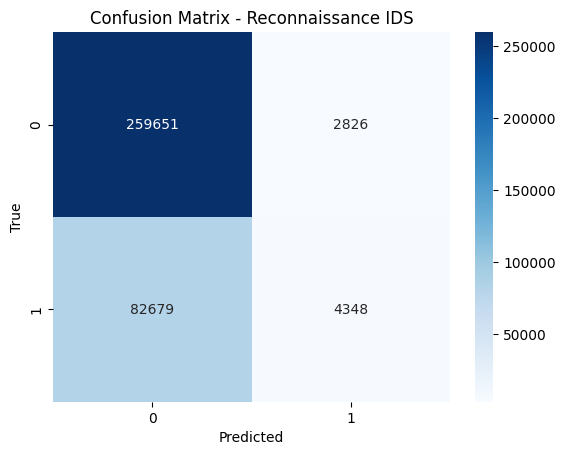

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Reconnaissance IDS")
plt.show()


<b>Aperçu des performances</b>

Accuracy globale : 0.76
→ À première vue, le modèle semble correct, mais attention : l’accuracy peut être trompeuse sur des classes déséquilibrées. Ici, la classe 0 (majoritaire) représente ~75 % des données, ce qui explique que l’accuracy soit relativement élevée même si le modèle ne détecte presque pas la classe 1.

<b>Interprétation :</b>

Classe 0 : Très bien détectée (rappel = 0.99), donc presque tous les vrais 0 sont correctement classés.

Classe 1 : Rappel catastrophique (0.05) → le modèle ne détecte quasiment aucun vrai 1. La précision est meilleure (0.61), ce qui signifie que quand le modèle prédit 1, il a 61 % de chances que ce soit correct. Mais c’est rare.

F1-score global pour la classe 1 : 0.09 → le modèle est pratiquement inutile pour détecter la classe minoritaire.

<b>Problème principal</b>

C’est un déséquilibre de classes.

Classe 0 : 262,477 exemples

Classe 1 : 87,027 exemples
→ ratio ~3:1

Le modèle tend naturellement à prédire la classe majoritaire pour maximiser l’accuracy. C’est pourquoi la classe minoritaire est presque ignorée.

<h3>Gestion du déséquilibre de classes</h3>

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,        # on peut augmenter un peu pour plus de stabilité
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # équilibre automatique entre classes
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<b>Ce que ça change pour notre problème</b>

Détection de la classe minoritaire améliorée
Grâce à class_weight='balanced', le modèle ne va plus ignorer les scans même s’ils sont moins fréquents que le trafic normal.

Arbres modérés (max_depth=10)
Évite le sur-apprentissage sur les patterns très spécifiques de certains devices.

Stabilité accrue (n_estimators=200)
Plus d’arbres → prédiction plus robuste et moins sensible au bruit.

Explicabilité
On pourra toujours regarder feature_importances_ pour identifier quelles features (ex : msg_per_sec) contribuent le plus à la détection.

<h3>Réévaluation</h3>

In [36]:
y_pred = rf.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.74      0.76    262477
           1       0.32      0.37      0.34     87027

    accuracy                           0.65    349504
   macro avg       0.55      0.56      0.55    349504
weighted avg       0.67      0.65      0.66    349504



<h3>Matrice de confusion améliorée</h3>

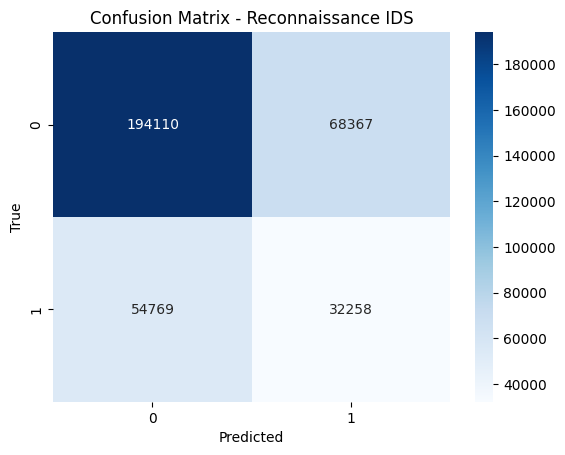

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Reconnaissance IDS")
plt.show()


<h3>Importance des features</h3>

In [38]:
import pandas as pd

feature_importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importances)


         feature  importance
0    msg_per_sec         1.0
1       mqtt_qos         0.0
2  mqtt_retained         0.0


<h3>Random Forest final</h3>


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1️⃣ Sélection des features (seule feature discriminante)
features = ["msg_per_sec"]
X = df_clean[features]
y = df_clean["label"]

# 2️⃣ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 3️⃣ Entraînement Random Forest avec class_weight pour la classe minoritaire
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# 4️⃣ Prédiction
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]  # Probabilité pour la classe 1

# 5️⃣ Classification report
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.78      0.74      0.76    262477
           1       0.32      0.37      0.34     87027

    accuracy                           0.65    349504
   macro avg       0.55      0.56      0.55    349504
weighted avg       0.67      0.65      0.66    349504



<H3>Matrice de confusion</H3>

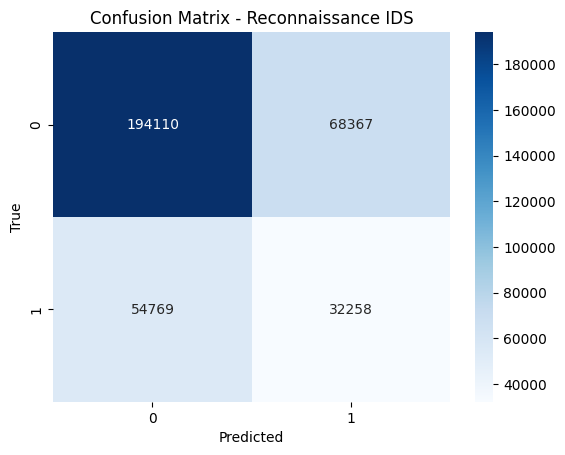

In [45]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Reconnaissance IDS")
plt.show()


<h3>ROC Curve</h3>

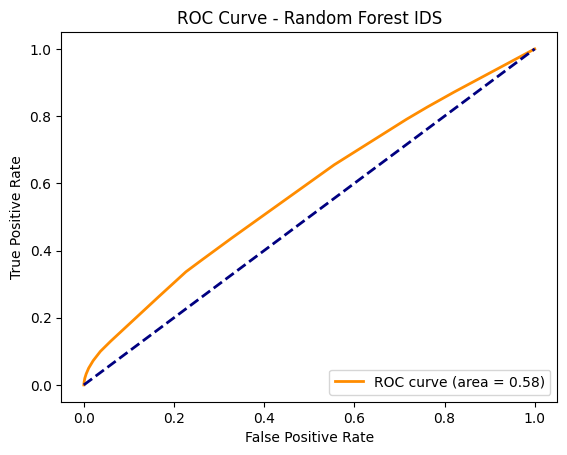

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest IDS')
plt.legend(loc="lower right")
plt.show()


<h3>Feature importance</h3>

In [47]:
feature_importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importances)


       feature  importance
0  msg_per_sec         1.0


<h1>Évaluation et interprétation</h1>

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.78      0.74      0.76    262477
           1       0.32      0.37      0.34     87027

    accuracy                           0.65    349504
   macro avg       0.55      0.56      0.55    349504
weighted avg       0.67      0.65      0.66    349504



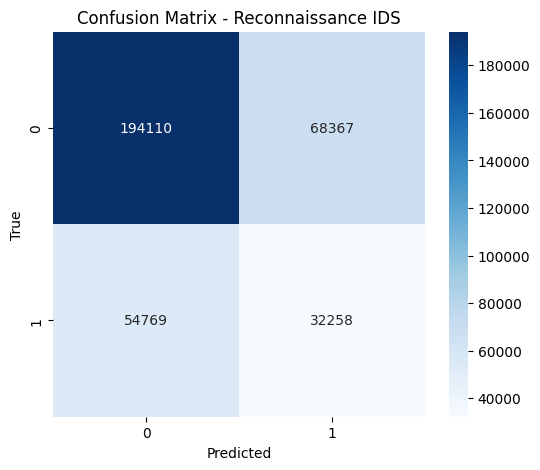

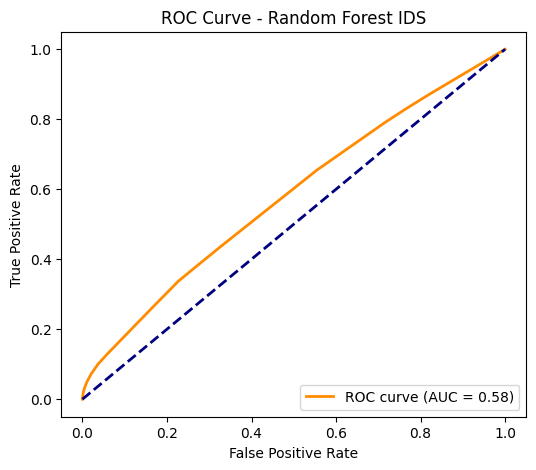

Nombre de Faux Positifs (FP) : 68367
Nombre de Faux Négatifs (FN) : 54769


In [48]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1️⃣ Classification report
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # probabilité pour la classe 1

print("===== Classification Report =====")
report = classification_report(y_test, y_pred)
print(report)

# 2️⃣ Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Reconnaissance IDS")
plt.show()

# 3️⃣ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest IDS')
plt.legend(loc="lower right")
plt.show()

# 4️⃣ Analyse des faux positifs / faux négatifs
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]

print(f"Nombre de Faux Positifs (FP) : {len(fp_idx)}")
print(f"Nombre de Faux Négatifs (FN) : {len(fn_idx)}")


<b>Observations clés :</b>

Classe 0 (normal)

Precision = 0.78 → quand le modèle prédit normal, c’est correct 78 % du temps.

Recall = 0.74 → 74 % des vrais normaux sont correctement détectés.

Classe 1 (Reconnaissance)

Precision = 0.32 → sur toutes les prédictions "scan", seulement 32 % sont correctes → beaucoup de FP.

Recall = 0.37 → seulement 37 % des scans réels sont détectés → beaucoup de FN, ce qui est critique pour IDS.

F1-score faible (0.34) pour les scans

Le modèle détecte partiellement les scans, mais beaucoup passent inaperçus ou sont mal classés.

<b>🔹 2️⃣ Analyse des faux positifs / faux négatifs</b>

Faux Positifs (FP) : 68,367

Le modèle a prédit scan alors que c’était normal → peut générer des alertes inutiles.

Dans un IDS opérationnel, il faut minimiser ces FP pour éviter la fatigue des analystes.

Faux Négatifs (FN) : 54,769

Le modèle n’a pas détecté ces scans → danger : ces attaques passent sous le radar.

Pour un IDS, les FN sont plus critiques que les FP.

<b>🔹 3️⃣ Analyse IDS</b>

La feature msg_per_sec seule n’est pas suffisante pour une détection robuste.

La plupart des erreurs viennent de :

Scans plus subtils (peu de messages/sec)

Scans combinés avec trafic normal

Stratégies d’amélioration :

Ajouter d’autres features réseau : bytes in/out, flags TCP, flux MQTT, entropie des payloads

Utiliser fenêtres temporelles plus fines pour capturer des rafales courtes

Essayer des modèles séquentiels LSTM ou CNN 1D pour capturer la dynamique des scans

<b>🔹 4️⃣ Visualisation et rapport</b>

La matrice de confusion montrera où se concentrent FP et FN.

La ROC curve + AUC donnera une mesure globale de séparation entre normal et scan.

<h1>2eme Méthodologies pour le Feature Engineering</h1>

<h3>1️⃣ Features temporelles</h3>

msg_per_sec / msg_per_window : comme avant, nombre de messages par fenêtre temporelle (ex : 1 sec ou 500 ms)

inter-arrival time : temps entre messages successifs pour détecter bursts ou scans rapides

rolling stats : moyenne, écart-type, max/min des messages par device dans une fenêtre

In [ ]:
import pandas as pd
import numpy as np

# Nettoyer les noms de colonnes
df_clean.columns = df_clean.columns.str.strip()

# Trier les données
df_clean = df_clean.sort_values(['general_device_name', '@timestamp'])
df_clean = df_clean.set_index('@timestamp')

# Fonction pour entropie
def shannon_entropy(x):
    probs = x.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

# Groupby par device + resample 1 seconde -> calculer toutes les features en une seule fois
features_df = df_clean.groupby('general_device_name').resample('1s').agg({
    'mqtt_message_value': 'count',               # msg_per_sec
    'mqtt_topic': ['nunique', shannon_entropy],  # topic_count, topic_entropy
    'mqtt_retained': 'mean',                     # ratio_retained
    'general_ip': 'nunique',                     # ip_count
    'general_mac': 'nunique',                    # mac_count
    'mqtt_qos': 'mean',                          # mqtt_qos moyen
    'mqtt_duplicate': 'mean'                     # mqtt_duplicate ratio
})

# Aplatir les colonnes multi-index
features_df.columns = ['msg_per_sec', 'topic_count', 'topic_entropy',
                       'ratio_retained', 'ip_count', 'mac_count',
                       'mqtt_qos', 'mqtt_duplicate']

# Remplacer NaN
features_df = features_df.fillna(0)

# Ajouter timestamp_diff par device
timestamp_diff = df_clean.groupby('general_device_name').apply(
    lambda g: g.index.to_series().diff().dt.total_seconds()
).reset_index(level=0, drop=True).reindex(features_df.index).fillna(0)
features_df['timestamp_diff'] = timestamp_diff

# Créer X et y
X = features_df
# Label par fenêtre 1s : si au moins un message est 1 -> fenêtre = 1
y = df_clean.groupby('general_device_name').resample('1s')['label'].max()
y = y.reindex(X.index, method='ffill')

print("Feature Engineering optimisé terminé, aperçu :")
print(X.head())
